CRS: EPSG:4326
Resolution (x, y): 0.0002777777777778173 0.0002777777777778173
Raster size (rows, cols): (202, 526)
Elevation range (m): 220.0 508.0


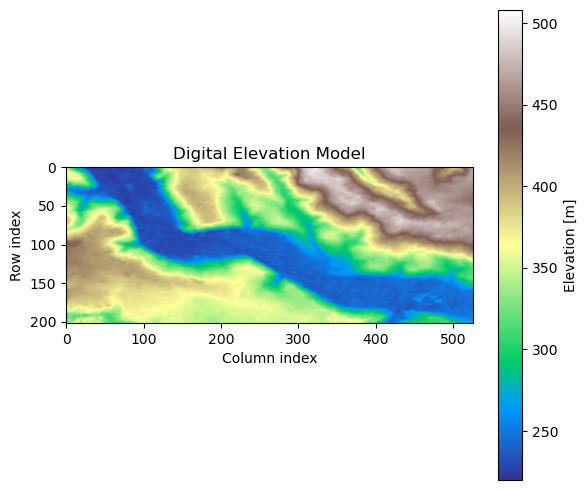

In [5]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt

# Path to DEM
dem_path = r"D:\!WAREM\Sem-3\Python\rasters_AW3D30\output_AW3D30.tif"

with rasterio.open(dem_path) as src:
    dem = src.read(1)
    dem_meta = src.meta
    dem_crs = src.crs
    dem_transform = src.transform
    nodata = src.nodata

# Mask NoData values
dem_masked = np.where(dem == nodata, np.nan, dem)

# Print key metadata
print("CRS:", dem_crs)
print("Resolution (x, y):", dem_transform.a, abs(dem_transform.e))
print("Raster size (rows, cols):", dem.shape)
print("Elevation range (m):",
      np.nanmin(dem_masked),
      np.nanmax(dem_masked))

# Plot DEM
plt.figure(figsize=(6, 5))
plt.imshow(dem_masked, cmap="terrain")
plt.colorbar(label="Elevation [m]")
plt.title("Digital Elevation Model")
plt.xlabel("Column index")
plt.ylabel("Row index")
plt.tight_layout()
plt.show()
